# SOFRESH Sea Surface Salinity

* Description: Dedicated regional Sea Surface Salinity (SSS) product in the Southern Ocean. Level 3 9-day maps. Data acquisition: Satellite ESA SMOS mission (Soil Moisture and Ocean Salinity). Time coverage 01 February 2011 - 31 December 2022. Time resolution: 9-day. Maps frequency generation: Daily. Spatial coverage: Latitude range: 30ºS-90ºS Longitude range: 180ºW-180ºE. Spatial resolution: 25 km (EASE-SL grid). Sensor Satellite SMOS / MIRAS.
* Original Data Source: https://digital.csic.es/handle/10261/332809
* Reference: https://essd.copernicus.org/articles/17/5089/2025/
* OSC entry: https://opensciencedata.esa.int/products/sofresh-sea-surface-salinity/collection
* License: CC-BY-4.0
* Repo Folder: ./datasets/so-fresh

In [1]:
import xarray as xr
import matplotlib.pyplot as plt

In [2]:
url = 'https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/polar_cube_datasets/so-fresh/sofresh.zarr/'

In [4]:
ds = xr.open_zarr(url)
ds

<xarray.Dataset> Size: 18GB
Dimensions:          (time: 4441, y: 720, x: 720, nv: 2)
Coordinates:
    lat              (y, x) float32 2MB dask.array<chunksize=(720, 720), meta=np.ndarray>
    lon              (y, x) float32 2MB dask.array<chunksize=(720, 720), meta=np.ndarray>
  * time             (time) datetime64[ns] 36kB 2011-02-01 ... 2023-03-30T23:...
  * x                (x) float32 3kB -8.988e+06 -8.962e+06 ... 8.988e+06
  * y                (y) float32 3kB 8.988e+06 8.962e+06 ... -8.988e+06
Dimensions without coordinates: nv
Data variables:
    crs              int32 4B ...
    sss              (time, y, x) float32 9GB dask.array<chunksize=(10, 720, 720), meta=np.ndarray>
    time_bnds        (time, nv) datetime64[ns] 71kB dask.array<chunksize=(4441, 2), meta=np.ndarray>
    uncertainty_sss  (time, y, x) float32 9GB dask.array<chunksize=(10, 720, 720), meta=np.ndarray>
Attributes: (12/35)
    date_created:             2023-07-12 06:14:00 GMT
    geospatial_x_units:       m
    geospatial_y_units:       m
    geospatial_x_resolution:  25000.0
    geospatial_y_resolution:  25000.0
    geospatial_x_min:         -9000000.0
    ...                       ...
    copyright:                If this data is used for publication, the follo...
    comment:                  This data was produced at BEC as part of the So...
    time_coverage_start:      20110201T00:00:00
    time_coverage_end:        1680217200000000000
    DOI:                      10.20350/digitalCSIC/15493
    title:                    Southern Ocean SMOS Level 3 Sea Surface Salinit...

In [5]:
da = ds['sss']
subset = da.sel(
    time=["2011-02-01", "2016-01-01", "2021-01-01"],
    method="nearest"
)

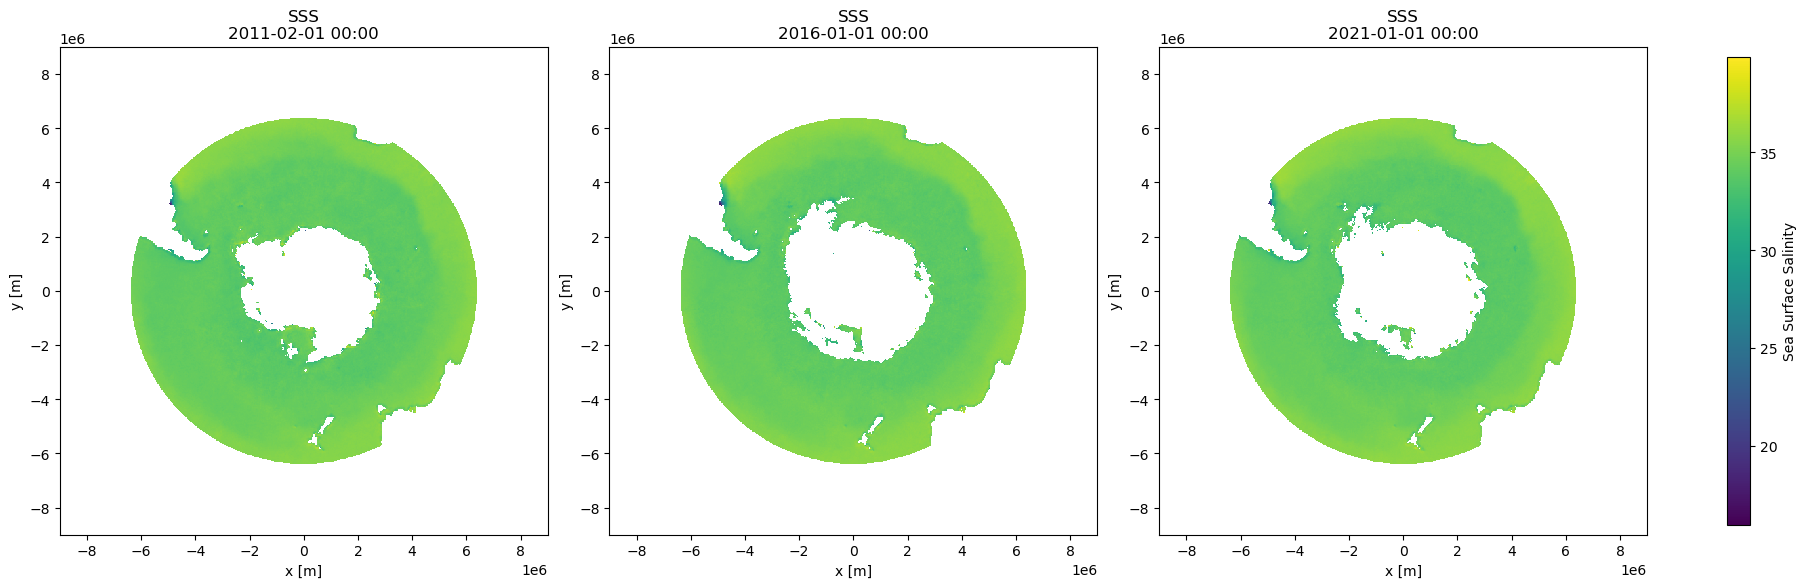

In [9]:
vmin = subset.min(skipna=True).values
vmax = subset.max(skipna=True).values

fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(18, 6),
    constrained_layout=True
)

for ax, t in zip(axes, subset.time):
    plot_data = da.sel(time=t)

    im = ax.pcolormesh(
        ds["x"],
        ds["y"],
        plot_data,
        shading="auto",
        vmin=vmin,
        vmax=vmax,
        cmap="viridis"
    )

    ax.set_title(f"SSS\n{t.dt.strftime('%Y-%m-%d %H:%M').item()}")
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.set_aspect("equal")

# shared colorbar
cbar = fig.colorbar(im, ax=axes, orientation="vertical", shrink=0.8)
cbar.set_label("Sea Surface Salinity")

plt.show()